# Notebook 1: Exploratory Data Analysis (EDA) & Data Cleaning
**Objective:** Load the raw Spotify dataset, inspect the data types, handle missing values, and perform necessary feature engineering (the "Transform" step in ETL) to prepare the data for Machine Learning.

In [6]:
import pandas as pd

# Load the raw dataset
# (Note: Update this path if your raw data is stored elsewhere)
df = pd.read_csv('data/spotify_tracks.csv')

# Drop the unnecessary 'Unnamed: 0' index column that exports sometimes generate
df = df.drop(columns=['Unnamed: 0'])

# Preview the first few rows
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### 1. Initial Dataset Inspection
Before cleaning, we need to understand the shape of our data, the data types, and the statistical spread of our audio features.

In [7]:
# Check structure, data types, and look for obvious missing data
print("DATASET INFO:")
df.info()

print("\nCOLUMN NAMES:")
print(df.columns)

# Summary statistics for our numerical audio features
df.describe()

DATASET INFO:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence          

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### 2. Handling Missing Data
Machine Learning models will crash if they encounter `NaN` (null) values. We need to identify if any tracks are missing critical metadata (like the artist or track name) and remove them from our pipeline.

In [8]:
# Create a filter that looks for missing (null) values in critical columns
missing_rows = df[df['artists'].isnull() | df['album_name'].isnull() | df['track_name'].isnull()]

print(f"Found {len(missing_rows)} rows with missing critical metadata.")
print("Example of missing data:")
print(missing_rows.head())

# Drop the missing rows and create our official 'df_clean' dataframe
df_clean = df.dropna(subset=['artists', 'album_name', 'track_name']).copy()
print(f"\nRemaining rows after cleaning: {len(df_clean)}")

Found 1 rows with missing critical metadata.
Example of missing data:
                     track_id artists album_name track_name  popularity  \
65900  1kR4gIb7nGxHPI3D2ifs59     NaN        NaN        NaN           0   

       duration_ms  explicit  danceability  energy  key  loudness  mode  \
65900            0     False         0.501   0.583    7     -9.46     0   

       speechiness  acousticness  instrumentalness  liveness  valence  \
65900       0.0605          0.69           0.00396    0.0747    0.734   

         tempo  time_signature track_genre  
65900  138.391               4       k-pop  

Remaining rows after cleaning: 113999


### 3. The "Shared Name" Mystery (Duplicate Analysis)
A common issue in music datasets is duplicate tracks. However, a track might appear multiple times if it was released as a Single, on an Album, and on a Compilation, or if Spotify categorized it under multiple different genres (e.g., "Pop" and "Synth-Pop"). 

Instead of blindly deleting these "clones," we will inspect them. Keeping clones in the dataset can actually act as a weight—teaching the ML model that highly duplicated (popular) songs are stronger recommendations.

In [9]:
# Find all rows that share the exact same artist and track name
# 'keep=False' tells Python: "Show me EVERY copy, don't hide the original!"
all_clones = df_clean[df_clean.duplicated(subset=['artists', 'track_name'], keep=False)]

# Sort them alphabetically by artist and track name so the clones sit right next to each other
all_clones = all_clones.sort_values(['artists', 'track_name'])

# The dataset is too wide to read easily, so let's just print the columns that explain the mystery
columns_to_view = ['artists', 'track_name', 'album_name', 'track_genre', 'popularity']
print(f"Found {len(all_clones)} cloned rows. Here is a sample:")
print(all_clones[columns_to_view].head(20))

Found 49157 cloned rows. Here is a sample:
           artists                 track_name  \
58516   (Hed) P.E.                 Crazy Legs   
58857   (Hed) P.E.                 Crazy Legs   
58306   (Hed) P.E.             Waiting to Die   
58874   (Hed) P.E.             Waiting to Die   
63488      10-FEET                      SHOES   
100702     10-FEET                      SHOES   
8319          10cc         Art For Art's Sake   
34690         10cc         Art For Art's Sake   
99694         10cc         Art For Art's Sake   
102694        10cc         Art For Art's Sake   
8321          10cc  The Things We Do For Love   
34691         10cc  The Things We Do For Love   
99695         10cc  The Things We Do For Love   
102695        10cc  The Things We Do For Love   
44373    12 Stones    Anthem For The Underdog   
47965    12 Stones    Anthem For The Underdog   
44276    12 Stones                 We Are One   
47654    12 Stones                 We Are One   
44309    12 Stones        

### 4. Feature Engineering & Sanity Checks
To make the data more human-readable, we will engineer a new feature: converting `duration_ms` into `duration_min`. Finally, we run sanity checks to ensure there are no impossible values in our math (like a song with 0 BPM or 0 length).

In [10]:
# Feature Engineering: Create a readable 'duration_min' column
df_clean['duration_min'] = df_clean['duration_ms'] / 60000

# Sanity Checks: Look for impossible values
impossible_tempo = df_clean[df_clean['tempo'] == 0]
impossible_duration = df_clean[df_clean['duration_min'] == 0]

print(f"Songs with 0 BPM tempo: {len(impossible_tempo)}")
print(f"Songs with 0 duration: {len(impossible_duration)}")

# Lets look at the final, transformed data
print("\nFinal Transformed Data Sample:")
print(df_clean[['artists', 'track_name', 'duration_min', 'tempo']].head())

df_clean.to_csv('data/cleaned_spotify_tracks.csv', index=False)

Songs with 0 BPM tempo: 157
Songs with 0 duration: 0

Final Transformed Data Sample:
                  artists                  track_name  duration_min    tempo
0             Gen Hoshino                      Comedy      3.844433   87.917
1            Ben Woodward            Ghost - Acoustic      2.493500   77.489
2  Ingrid Michaelson;ZAYN              To Begin Again      3.513767   76.332
3            Kina Grannis  Can't Help Falling In Love      3.365550  181.740
4        Chord Overstreet                     Hold On      3.314217  119.949


### 5. Correlation Analysis: Finding the Musical Formula
To understand how different audio features interact with one another, we will build a correlation heatmap. This helps us identify if certain traits naturally move together (e.g., do loud songs tend to have higher energy?).

* **Dark Red (1.0):** Strong positive relationship (they increase together).
* **Dark Blue (-1.0):** Strong negative relationship (as one increases, the other decreases).
* **White/Grey (0):** No mathematical relationship.

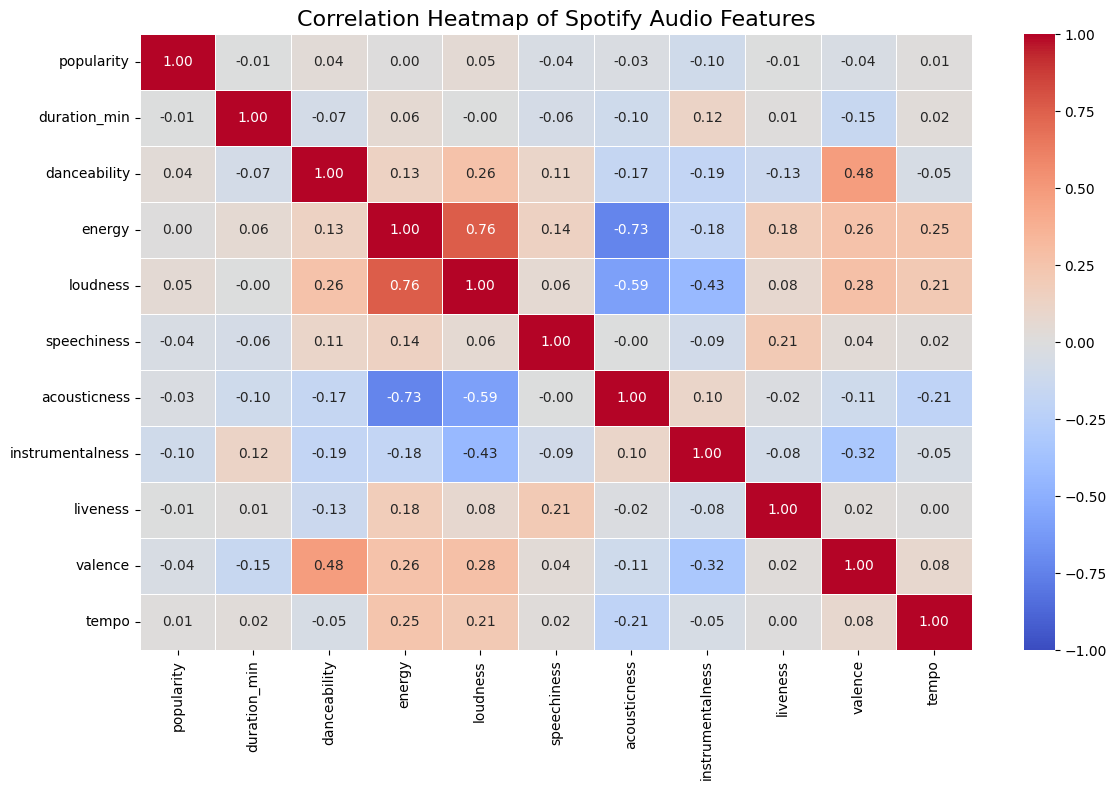

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select only the numerical audio features for correlation analysis
numerical_columns = [
    'popularity', 'duration_min', 'danceability', 'energy', 
    'loudness', 'speechiness', 'acousticness', 
    'instrumentalness', 'liveness', 'valence', 'tempo'
]

# 2. Compute the correlation matrix
correlation_matrix = df_clean[numerical_columns].corr()

# 3. Set up a large canvas
plt.figure(figsize=(12, 8))

# 4. Draw the heatmap using seaborn
sns.heatmap(correlation_matrix, 
            annot=True,             # writes the actual numbers inside the coloured boxes
            cmap='coolwarm',        # color theme: blue for negative, red for positive
            fmt=".2f",              # rounds the number to 2 decimal places
            linewidths=0.5,         # adds a tiny white border between the boxes
            vmin=-1, vmax=1         # set the range of the color scale from -1 to 1
)

# 5. Add title and show the plot
plt.title("Correlation Heatmap of Spotify Audio Features", fontsize=16)
plt.tight_layout()                  
plt.show()

#### Heatmap Takeaways
1. **The Energy/Loudness Bond:** The strongest positive correlation in the dataset is between Loudness and Energy (**0.76**).
2. **The Acoustic Trade-Off:** There is a massive negative correlation between Energy and Acousticness (**-0.76**), as well as Loudness and Acousticness (**-0.59**). 
3. **The Happiness/Groove Link:** There is a notable correlation between Valence (happiness) and Danceability (**0.48**). Songs that are highly danceable are generally more positive and upbeat.

**💡 The Plot Twist (Popularity):**
There is no concrete correlation between `popularity` and *any* of the other audio categories. This mathematically proves there is no distinct audio "formula" to create a hit song. Popularity is likely driven by external features outside of this dataset, such as artist fame, TikTok trends, marketing budgets, or Spotify editorial playlist placements.

### 6. Genre Audio Signatures (Radar Chart)
To visualize how different genres utilize these audio features, we can build a polar Radar Chart. By plotting the averages on a 0.0 to 1.0 scale, we can see the exact "mathematical shape" or signature of a specific genre.

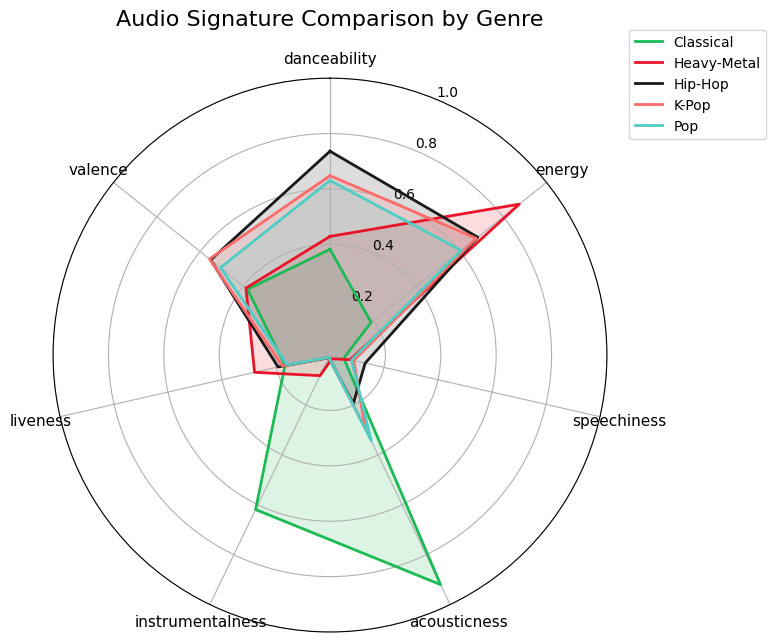

In [12]:
import numpy as np

# 1. Select the features that are measured on a 0.0 to 1.0 scale
features = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']

# 2. Group the data by genre and calculate the average for each feature
genre_averages = df_clean.groupby('track_genre')[features].mean()

# 3. Pick five very different genres to compare
genres_to_compare = ['classical', 'heavy-metal', 'hip-hop', 'k-pop', 'pop']
data_to_plot = genre_averages.loc[genres_to_compare]

# 4. Math setup to draw a circle (Radar charts use polar coordinates)
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]  # Close the circle

# 5. Set up the canvas
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# 6. Draw a shape for each genre
colors = ['#1db954', '#e91429', '#1a1a1a', '#ff6b6b', '#4ecdc4'] 

for idx, (genre, color) in enumerate(zip(genres_to_compare, colors)):
    values = data_to_plot.loc[genre].tolist()
    values += values[:1]  # Close the circle
    
    # Plot the outline and fill it in
    ax.plot(angles, values, color=color, linewidth=2, label=genre.title())
    ax.fill(angles, values, color=color, alpha=0.15)

# 7. Add the labels and formatting
ax.set_theta_offset(np.pi / 2) # Put the first label at the very top
ax.set_theta_direction(-1)     # Go clockwise
ax.set_thetagrids(np.degrees(angles[:-1]), features, fontsize=11)

# Set the scale from 0 to 1 so it matches the data perfectly
ax.set_ylim(0, 1)

plt.title('Audio Signature Comparison by Genre', y=1.08, fontsize=16)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

#### Radar Chart Takeaways
* **The Outlier:** Classical spikes heavily toward the bottom (Acousticness and Instrumentalness), completely avoiding the Energy and Danceability zones where modern commercial music lives.
* **The "Twin" Genres:** Pop and K-Pop share an almost identical shape (high energy, high danceability, high valence). This proves mathematically that they share the exact same musical DNA and target the same psychological response, just in different languages.
* **Anger vs. Groove:** Heavy-Metal stretches to the absolute limit of Energy but scores very low on Danceability and Valence. Hip-Hop, meanwhile, dominates the Danceability and Speechiness axes.